# Seismic Tomography: Classical Inversion vs. Physics-Informed Neural Networks

## Introduction

Seismic tomography is a technique used to image the subsurface of the Earth by 
inverting measured seismic travel times for the velocity (or slowness) structure 
of the medium. Travel time $t$ along a ray path through a medium with 
slowness $s(\mathbf{x}) = 1/v(\mathbf{x})$ is given by:
$$t = s(\mathbf{x}) \, d\ell$$

In practice, we discretize the domain into $N$ blocks and approximate this as a 
linear system:

$$\mathbf{d} = \mathbf{G} \, \delta\mathbf{s}$$

where $\mathbf{d}$ is the vector of observed travel-time anomalies (relative to a 
reference model), $\mathbf{G}$ is the ray-path matrix (path length of ray $i$ 
through block $j$), and $\delta\mathbf{s}$ is the slowness perturbation we want 
to recover.

## Research Question

**Can a Physics-Informed Neural Network (PINN) recover a synthetic low-velocity 
anomaly from seismic travel-time data as accurately as classical regularized 
tomographic inversion?**

## Approach

This project compares two inversion methods on a synthetic 2D slowness model:

1. **Eikonal PINN**: A separate PINN trained to solve the eikonal equation 
   $|\nabla T|^2 = s^2$, providing the forward travel-time field 
2. **Classical tomographic inversion**: Damped least-squares with a 2D 
   smoothing regularizer (Tikhonov regularization)
3. **Tomographic PINN**: A neural network trained directly on the travel-time 
   data with a smoothness regularization term embedded in the loss function

The eikonal PINN (1) is trained first to validate that the physics (forward problem) can be recovered before tomoPINN (3) attempts the inverse problem in Part 3.


## Data

All data are fully synthetic. The "true" model is a 20×20 grid on a 1000×1000 km 
domain containing:

- A **heart-shaped low-velocity zone** (LVZ) at the domain center 
  ($s_\mathrm{low} = 0.264$ s/km)

- A **checkerboard pattern** of high-velocity anomalies outside the heart 
  ($s_\mathrm{high} = 0.187$ s/km)

- A **background slowness** of $s_\mathrm{bg} = 0.220$ s/km

118 synthetic ray paths cross the domain, and 5% Gaussian noise is added to 
the travel-time data.

The ray-path matrix, forward problem, and classical inversion code is adapted 
from a tomography notebook by Weiqiang Zhu for EPS130 at UC Berkeley, with 
modifications to the velocity model and synthetic data setup. The theoretical background for seismic travel-time tomography and the linearized inversion framework follows Shearer (2019, Ch. 2–5). The PINN architecture follows some of the framework introduced by Raissi et al. (2019). The eikonal PINN implementation uses approach of Smith et al.(2021). The general PINN training methodology was also informed by the lecture by Brunton (2024).



# Synthetic Model and Ray Coverage

The true model contains a heart-shaped slow anomaly (blue) on a 
checkerboard of fast anomalies (red). The ray coverage map shows the cumulative 
path length fraction of all 118 rays through each block. The coverage is 
heterogeneous. Blocks near the edges and corners are sampled by fewer 
rays, which will limit inversion quality at those points.

In [ ]:

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.linalg import inv

# PART 0: Making synthetic slowness model 

# Unit square domain [0,1] x [0,1], 20x20 grid

lon_new = np.linspace(0, 1, 20)   # x axis [0,1]
lat_new = np.linspace(0, 1, 20)   # y axis [0,1]

# Background slowness 
s_bg    = 0.220   # s/km

# Anomaly slowness
s_low  = 0.264    # slow = low-velocity zone   
s_high = 0.187    # fast = high-velocity zone 

# Normalized grid [0,1]
xi = np.linspace(0, 1, 20)
yi = np.linspace(0, 1, 20)
XI, YI = np.meshgrid(xi, yi, indexing='ij')   # shape (20,20), x=row, y=col

# Heart-shaped low-velocity anomaly (center of domain)
# Parametric heart: rotated so it points up

cx, cy = 0.5, 0.5       # center
scale  = 0.22           # heart size

# Just to rotate the heart
raw_x = (XI - cx) / scale
raw_y = (YI - cy) / scale
dx_h =  -raw_y        # rotated x
dy_h = raw_x          # rotated y

# Classic heart implicit
heart_mask = (dx_h**2 + dy_h**2 - 1)**3 - dx_h**2 * dy_h**3 <= 0

# Checkerboard: 

# 20 grid points / 4 cells = 5 points per cell 
checker = ((np.floor(XI * 4) + np.floor(YI * 4)) % 2).astype(bool)
# High-vel only outside heart, on checker darker squares
high_mask = checker & ~heart_mask


s_true = np.full((20, 20), s_bg)
s_true[heart_mask]  = s_low    # heart = low velocity (slow)
s_true[high_mask]   = s_high   # checkerboard patches = high velocity (fast)

s_mean = s_true.mean()
ds_true = s_true.ravel() - s_mean

print(f"s_true range: {s_true.min():.4f} – {s_true.max():.4f} s/km")
print(f"ds_true range: {ds_true.min():.4f} – {ds_true.max():.4f} s/km")
print(f"s_mean: {s_mean:.4f} s/km")




s_true range: 0.1870 – 0.2640 s/km
ds_true range: -0.0266 – 0.0504 s/km
s_mean: 0.2136 s/km


In [ ]:

# PART 1: Classical tomographic inversion 

# Synthetic G matrix: random ray paths across 20x20 grid
# 118 rays, 400 blocks
n_rays   = 118
n_blocks = 20 * 20

# Square physical domain — 1000x1000 km, 50 km blocks
Lx = 1000.0   # km
Ly = 1000.0   # km
block_km = Lx / 20


np.random.seed(0)
# Each ray: random start and end point on domain boundary
# Path length through each block = intersection length (approximated)
# Simple model: each ray touches sqrt(n_blocks) blocks on average


G_raw = np.zeros((n_rays, n_blocks))

for r in range(n_rays):
    # Random source on left/bottom edge, receiver on right/top edge
    if np.random.rand() < 0.5:
        x0, x1 = 0.0, 1.0                          # left to right
        y0 = np.random.rand()
        y1 = np.random.rand()
    else:
        y0, y1 = 0.0, 1.0                          # bottom to top
        x0 = np.random.rand()
        x1 = np.random.rand()

    # Sample points along ray, find which block each hits
    n_steps = 200
    ts = np.linspace(0, 1, n_steps)
    xs = x0 + ts * (x1 - x0)
    ys = y0 + ts * (y1 - y0)
    ix = (xs * 20).astype(int).clip(0, 19)
    iy = (ys * 20).astype(int).clip(0, 19)
    block_ids = iy * 20 + ix
    for b in block_ids:
        G_raw[r, b] += 1.0 / n_steps   # path length fraction

G = G_raw * block_km                  # G_ij-matrix 


# Forward data
d_clean = G @ ds_true
np.random.seed(42)
d_noisy = d_clean + 0.05 * np.random.randn(n_rays)

print(f"G shape: {G.shape}")
print(f"ds_true range: {ds_true.min():.4f} – {ds_true.max():.4f} s/km")
print(f"d_clean range: {d_clean.min():.3f} – {d_clean.max():.3f} s")

# Smoothing / regularisation matrix
def smoothing_matrix_2d(nx, nz):
    n = nx * nz
    rows = []
    for iz in range(nz):
        for ix in range(nx):
            k = iz * nx + ix
            if ix < nx - 1:
                row = np.zeros(n); row[k] = -1; row[k+1] = 1
                rows.append(row)
            if iz < nz - 1:
                row = np.zeros(n); row[k] = -1; row[k+nx] = 1
                rows.append(row)
    return np.array(rows)

L   = smoothing_matrix_2d(20, 20)
LtL = L.T @ L
alpha = 0.1
ds_classical = np.linalg.inv(G.T @ G + alpha**2 * LtL) @ G.T @ d_noisy


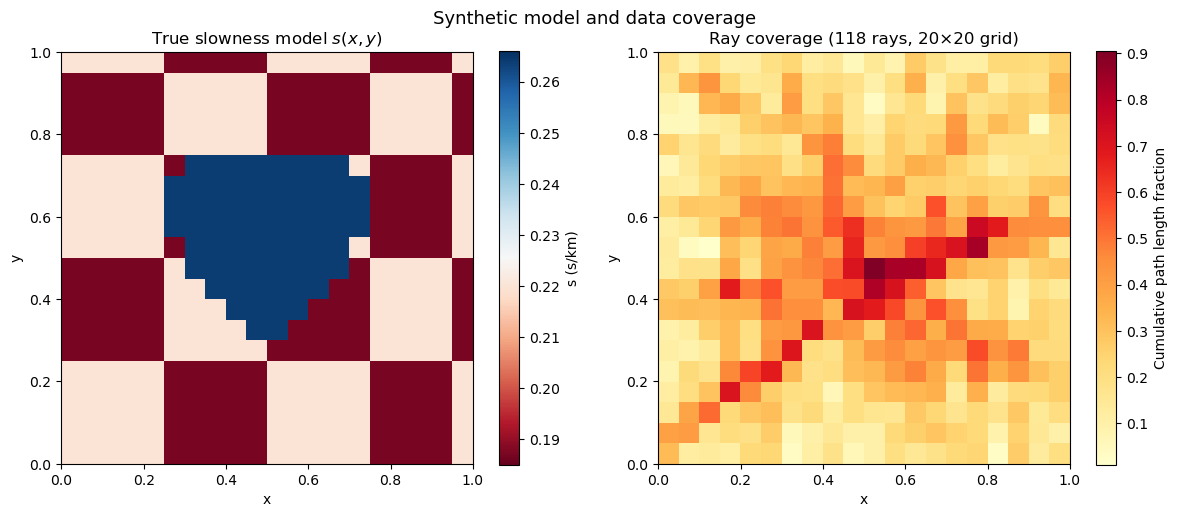

In [70]:
# Ray coverage: how many rays pass through each block
coverage = G_raw.sum(axis=0).reshape(20, 20)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True slowness model
im0 = axes[0].imshow(s_true, aspect='equal', cmap='RdBu',
                     extent=[0,1,0,1], origin='lower',
                     vmin=s_high-0.002, vmax=s_low+0.002)
axes[0].set_title('True slowness model $s(x,y)$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
plt.colorbar(im0, ax=axes[0], label='s (s/km)')

# Ray coverage
im1 = axes[1].imshow(coverage, aspect='equal', cmap='YlOrRd',
                     extent=[0,1,0,1], origin='lower')
axes[1].set_title(f'Ray coverage ({n_rays} rays, 20×20 grid)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
plt.colorbar(im1, ax=axes[1], label='Cumulative path length fraction')

plt.suptitle('Synthetic model and data coverage', fontsize=13)
plt.tight_layout(); plt.show()

## Eikonal PINN vs. PDE

In [ ]:

# PART 2: Eikonal PINN (forward problem)
# PDE: |∇τ|² = s(x,y)² at source at domain centre

Lx_eik = Lx
Ly_eik = Ly
L_scale = (Lx_eik + Ly_eik) / 2.0
print(f"Domain: Lx={Lx_eik:.1f} km, Ly={Ly_eik:.1f} km, L_scale={L_scale:.1f} km")

class EikonalPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
    def forward(self, x, y):
        xn = (x - 0.5) / 0.5   # normalise to [-1,1]
        yn = (y - 0.5) / 0.5
        out = self.net(torch.cat([xn, yn], dim=1))
        return torch.abs(out)
    

# PDE residual computation via autograd — no finite differences
# Eikonal equation: |∇τ|² = s(x,y)²
# where τ = r * T(x,y), r = distance from source, T = NN output

def loss_eikonal(model, x_col, y_col, s_col):

    x_col = x_col.requires_grad_(True)
    y_col = y_col.requires_grad_(True)
    x_src = torch.tensor([[0.5]], dtype=torch.float32)
    y_src = torch.tensor([[0.5]], dtype=torch.float32)

    r = torch.sqrt((x_col - x_src)**2 + (y_col - y_src)**2 + 1e-6)
    T = model(x_col, y_col)
    tau = r * T             # physical travel time field


    # ∂τ/∂x and ∂τ/∂y via automatic differentiation
    dtau_dx = torch.autograd.grad(tau, x_col,
                grad_outputs=torch.ones_like(tau), create_graph=True)[0]
    dtau_dy = torch.autograd.grad(tau, y_col,
                grad_outputs=torch.ones_like(tau), create_graph=True)[0]
    
    # Eikonal residual: (∂τ/∂x)² + (∂τ/∂y)² - s² = 0 if PDE satisfied
    # Large residual = network violates the eikonal equation badly there
    # Loss forces residual to 0 during training
    residual= dtau_dx**2 + dtau_dy**2 - s_col**2 
    return torch.mean(residual**2)

# No grid needed: 2000 random (x,y) collocation points scattered across domain
# Network predicts T at each point, then checks whether eikonal PDE is satisfied
n_col_eik = 2000
x_col_eik = torch.rand(n_col_eik, 1, dtype=torch.float32)
y_col_eik = torch.rand(n_col_eik, 1, dtype=torch.float32)

# Slowness at collocation points (nearest-neighbour from s_true)
x_idx = (x_col_eik.numpy() * 19).astype(int).clip(0, 19)
y_idx = (y_col_eik.numpy() * 19).astype(int).clip(0, 19)
s_col_eik = torch.tensor(
    s_true[x_idx.ravel(), y_idx.ravel()].reshape(-1, 1),
    dtype=torch.float32
)
print(f"s_col range: {s_col_eik.min():.4f} – {s_col_eik.max():.4f} s/km")


In [ ]:
# Training loop with Adam optimizer and cosine annealing scheduler
# Each epoch:

model_eik   = EikonalPINN()

losses_eik  = []
optimizer_eik = torch.optim.Adam(model_eik.parameters(), lr=1e-3)
scheduler_eik = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_eik, T_max=20000, eta_min=1e-5)

for epoch in range(20000):
    optimizer_eik.zero_grad()
    loss = loss_eikonal(model_eik, x_col_eik, y_col_eik, s_col_eik)
    loss.backward()
    optimizer_eik.step()
    scheduler_eik.step()
    losses_eik.append(loss.item())
    
    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d}  Loss: {loss.item():.6f}")

# 1. Takes current network weights
# 2. Computes eikonal PDE residual loss
# 3. Computes gradients via backpropagation
# 4. Takes one small step to reduce the loss
# 5. Repeats

# Evaluate on 20×20 grid
x_grid = torch.linspace(0, 1, 20, dtype=torch.float32)
y_grid = torch.linspace(0, 1, 20, dtype=torch.float32)
Xg, Yg = torch.meshgrid(x_grid, y_grid, indexing='ij')
x_data = Xg.reshape(-1, 1)
y_data = Yg.reshape(-1, 1)

x_grid_np = np.linspace(0, 1, 20)
y_grid_np = np.linspace(0, 1, 20)
Xg_np, Yg_np = np.meshgrid(x_grid_np, y_grid_np, indexing='ij')

# Evaluate on 20×20 grid
with torch.no_grad():
    T_pred = model_eik(x_data, y_data).squeeze().numpy().reshape(20, 20)

r_normalized      = np.sqrt((Xg_np - 0.5)**2 + (Yg_np - 0.5)**2)
tau_ref           = r_normalized * L_scale * s_true.mean()          # homogeneous reference (mean slowness, no anomaly)
tau_pred_physical = r_normalized * T_pred * L_scale                 # Recover physical travel time


In [66]:
print(f"G shape: {G.shape}")
print(f"ds_true range: {ds_true.min():.4f} – {ds_true.max():.4f} s/km")
print(f"d_clean range: {d_clean.min():.3f} – {d_clean.max():.3f} s")

print(f"ds_classical range: {ds_classical.min():.4f} – {ds_classical.max():.4f} s/km")
print(f"Domain: Lx={Lx_eik:.1f} km, Ly={Ly_eik:.1f} km, L_scale={L_scale:.1f} km")
print(f"s_col range: {s_col_eik.min():.4f} – {s_col_eik.max():.4f} s/km")

G shape: (118, 400)
ds_true range: -0.0266 – 0.0504 s/km
d_clean range: -0.813 – 1.184 s
ds_classical range: -0.0429 – 0.0731 s/km
Domain: Lx=1000.0 km, Ly=1000.0 km, L_scale=1000.0 km
s_col range: 0.1870 – 0.2640 s/km


Epoch     0 Loss: 0.002072
Epoch  2000 Loss: 0.000037
Epoch  4000 Loss: 0.000033
Epoch  6000 Loss: 0.000026
Epoch  8000 Loss: 0.000023
Epoch 10000 Loss: 0.000021
Epoch 12000 Loss: 0.000020
Epoch 14000 Loss: 0.000018
Epoch 16000 Loss: 0.000017
Epoch 18000 Loss: 0.000016


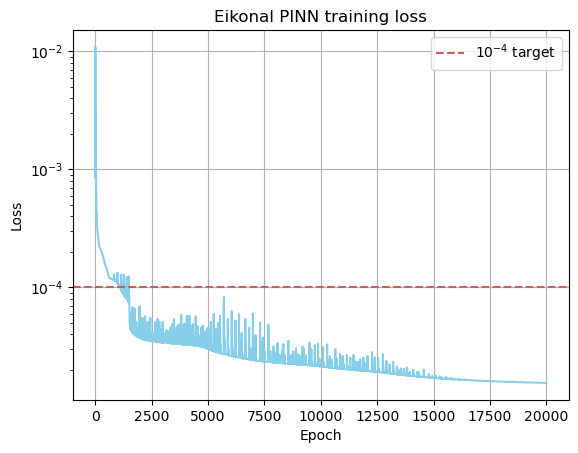

In [143]:
for i, loss_val in enumerate(losses_eik):
    if i % 2000 == 0:
        print(f"Epoch {i:5d} Loss: {loss_val:.6f}")

plt.semilogy(losses_eik, color='skyblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Eikonal PINN training loss')
plt.axhline(1e-4, color='indianred', linestyle='--', label='$10^{-4}$ target')
plt.grid(True);plt.legend(); plt.show()


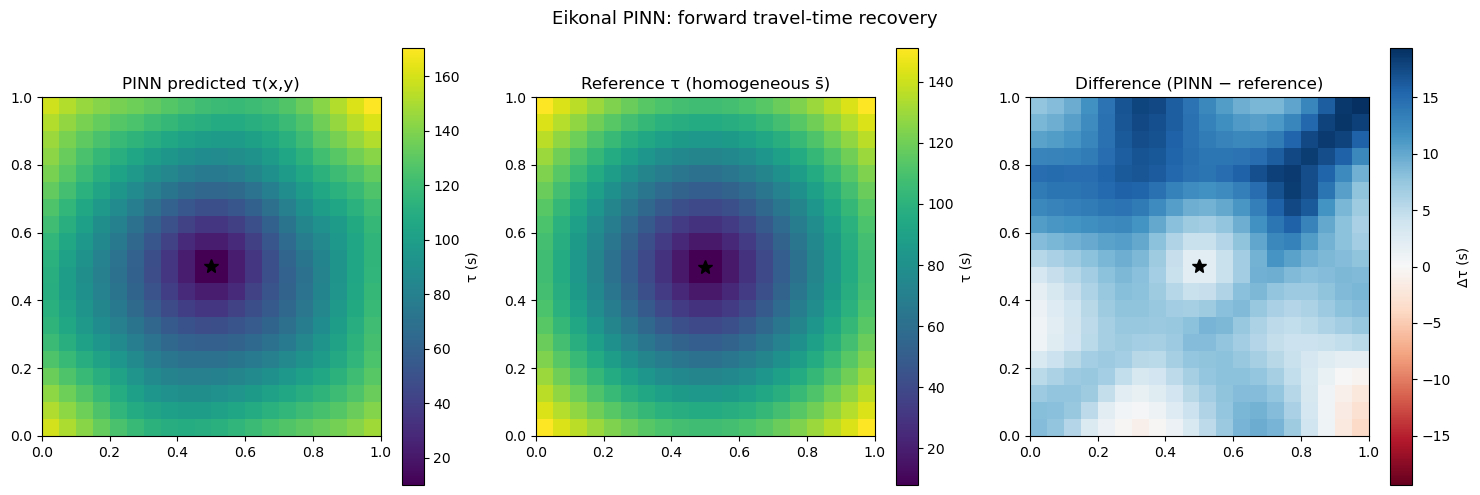

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Predicted travel time
im0 = axes[0].imshow(tau_pred_physical, aspect='equal', cmap='viridis',
                     extent=[0,1,0,1], origin='lower')
axes[0].set_title('PINN predicted τ(x,y)')
plt.colorbar(im0, ax=axes[0], label='τ (s)')

# Homogeneous reference
im1 = axes[1].imshow(tau_ref, aspect='equal', cmap='viridis',
                     extent=[0,1,0,1], origin='lower')
axes[1].set_title('Reference τ (homogeneous s̄)')
plt.colorbar(im1, ax=axes[1], label='τ (s)')

# Difference
diff_tau = tau_pred_physical - tau_ref
im2 = axes[2].imshow(diff_tau, aspect='equal', cmap='RdBu',
                     extent=[0,1,0,1], origin='lower',
                     vmin=-np.abs(diff_tau).max(), vmax=np.abs(diff_tau).max())
axes[2].set_title('Difference (PINN − reference)')
plt.colorbar(im2, ax=axes[2], label='Δτ (s)')

for ax in axes:
    ax.plot(0.5, 0.5, 'k*', markersize=10)

plt.suptitle('Eikonal PINN: forward travel-time recovery', fontsize=13)
plt.tight_layout(); plt.show()

## Results  Eikonal PINN vs. PDE

The eikonal PINN solved the forward problem, where the slowness field is given and the network predicts the travel-time field τ(x,y). The source is placed at [0.5, 0.5]. The loss converged to $1.6 x 10^{-5}$, which is below the target at $10^{-4}$. In this case, the eikonal PDE is satifsfied. 

The difference map shows higher travel times in the center, indicating that the PINN correctly predicts the low-velocity anomaly

# Tomographic PINN inversion 

In [ ]:
# PART 3: Tomographic PINN inversion 

class tomoPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
    def forward(self, x, y):
        xn = (x - 0.5) / 0.5             # normalise to [-1,1]
        yn = (y - 0.5) / 0.5
        out = self.net(torch.cat([xn, yn], dim=1))
        return out

def loss_tomo(model, x_col, y_col, x_data, y_data, d_obs_norm,
              G_norm, lambda_data=1.0):   
    
    # Data loss: predicted travel times vs observed                         
    ds_pred = model(x_data, y_data)
    d_pred  = G_norm @ ds_pred.squeeze()
    L_data  = torch.mean((d_pred - d_obs_norm)**2)

    # Smoothness loss: penalizes sharp gradients in the slowness field
    # via autograd, no finite differences
    x_col = x_col.requires_grad_(True)
    y_col = y_col.requires_grad_(True)
    s = model(x_col, y_col)
    ds_dx = torch.autograd.grad(s, x_col,
                                grad_outputs=torch.ones_like(s),
                                create_graph=True)[0]
    ds_dy = torch.autograd.grad(s, y_col,
                                grad_outputs=torch.ones_like(s),
                                create_graph=True)[0]
    L_smooth = torch.mean(ds_dx**2 + ds_dy**2)


    # Total loss: data fit + smoothness regularization (weight 0.0001)
    # large L_data = network violates observations
    # large L_smooth = network produces unphysically rough slowness field
    return lambda_data * L_data + 0.0001 * L_smooth


# 2000 random (x,y) collocation points - no grid needed
n_col   = 2000
x_col   = torch.rand(n_col, 1, dtype=torch.float32)
y_col   = torch.rand(n_col, 1, dtype=torch.float32)

# 20×20 grid points where we know the G matrix rows
x_data  = Xg.reshape(-1, 1)
y_data  = Yg.reshape(-1, 1)

# Normalise data by std to balance loss scale
d_scale     = d_noisy.std()
d_obs_norm  = torch.tensor(d_noisy / d_scale, dtype=torch.float32)
G_norm      = torch.tensor(G / d_scale, dtype=torch.float32)


# Had to add extra collocation points near source to improve coverage
n_src = 500
r_src = torch.rand(n_src, 1) * 0.15   # within 0.15 of source
theta  = torch.rand(n_src, 1) * 2 * np.pi
x_src_extra = 0.5 + r_src * torch.cos(theta)
y_src_extra = 0.5 + r_src * torch.sin(theta)
x_col_eik = torch.cat([x_col_eik, x_src_extra.clamp(0,1)])
y_col_eik = torch.cat([y_col_eik, y_src_extra.clamp(0,1)])



# Training loop
# each epoch: forward pass -> loss -> backprop -> weight update
model_pinn    = tomoPINN()
optimizer_pinn = torch.optim.Adam(model_pinn.parameters(), lr=1e-3)
scheduler_pinn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_pinn, T_max=3000, eta_min=1e-5)

losses_pinn = []

for epoch in range(30000):
    optimizer_pinn.zero_grad()
    loss = loss_tomo(model_pinn, x_col, y_col, x_data, y_data, d_obs_norm, G_norm)
    loss.backward()
    optimizer_pinn.step()   # ←
    scheduler_pinn.step()
    losses_pinn.append(loss.item())
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d}  Loss: {loss.item():.6f}")

with torch.no_grad():
    ds_pinn = model_pinn(x_data, y_data).squeeze().numpy()



rmse_pinn      = np.sqrt(np.mean((ds_true - ds_pinn)**2))
rmse_classical = np.sqrt(np.mean((ds_true - ds_classical)**2))
print(f"RMSE classical: {rmse_classical:.6f} s/km")
print(f"RMSE PINN:      {rmse_pinn:.6f} s/km")




Epoch     0  Loss: 4.966634
Epoch   500  Loss: 0.330831
Epoch  1000  Loss: 0.230086
Epoch  1500  Loss: 0.174043
Epoch  2000  Loss: 0.139602
Epoch  2500  Loss: 0.119595
Epoch  3000  Loss: 0.114562
Epoch  3500  Loss: 0.108184
Epoch  4000  Loss: 0.092217
Epoch  4500  Loss: 0.082731
Epoch  5000  Loss: 0.079173
Epoch  5500  Loss: 0.071004
Epoch  6000  Loss: 0.065730
Epoch  6500  Loss: 0.058499
Epoch  7000  Loss: 0.055226
Epoch  7500  Loss: 0.052615
Epoch  8000  Loss: 0.050626
Epoch  8500  Loss: 0.049586
Epoch  9000  Loss: 0.049320
Epoch  9500  Loss: 0.048950
Epoch 10000  Loss: 0.047974
Epoch 10500  Loss: 0.070269
Epoch 11000  Loss: 0.043256
Epoch 11500  Loss: 0.036671
Epoch 12000  Loss: 0.114023
Epoch 12500  Loss: 0.052876
Epoch 13000  Loss: 0.045342
Epoch 13500  Loss: 0.042014
Epoch 14000  Loss: 0.040062
Epoch 14500  Loss: 0.039145
Epoch 15000  Loss: 0.038922
Epoch 15500  Loss: 0.038619
Epoch 16000  Loss: 0.036919
Epoch 16500  Loss: 0.033326
Epoch 17000  Loss: 0.029769
Epoch 17500  Loss: 0

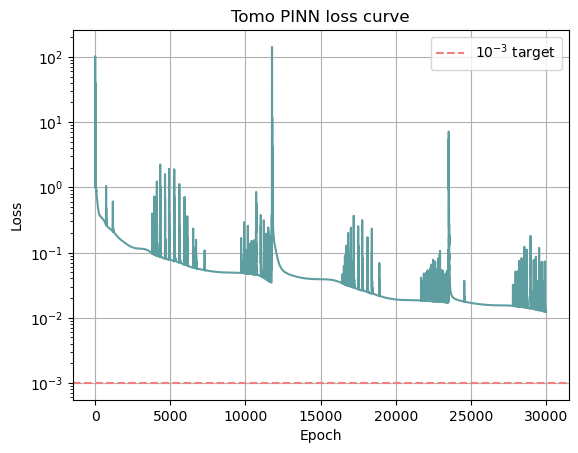

In [138]:
plt.semilogy(losses_pinn, color='cadetblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Tomo PINN loss curve')
plt.axhline(1e-3, color='lightcoral', linestyle='--', label='$10^{-3}$ target')
plt.legend()
plt.grid(True); plt.show()

The tomographic PINN loss curve are much more noicer than the eikonal loss. It has serveral large spikes during traning. This refelcts how the PINN strugles with the invers problem. The network finds it difficult to fit 118 noisy travel time as well as maintain smooth slowness field. The loss decreases from 4.9-0.013 over 30000 epochs, did not converge to the target threshold."

## Classical vs PINN — synthetic heart model

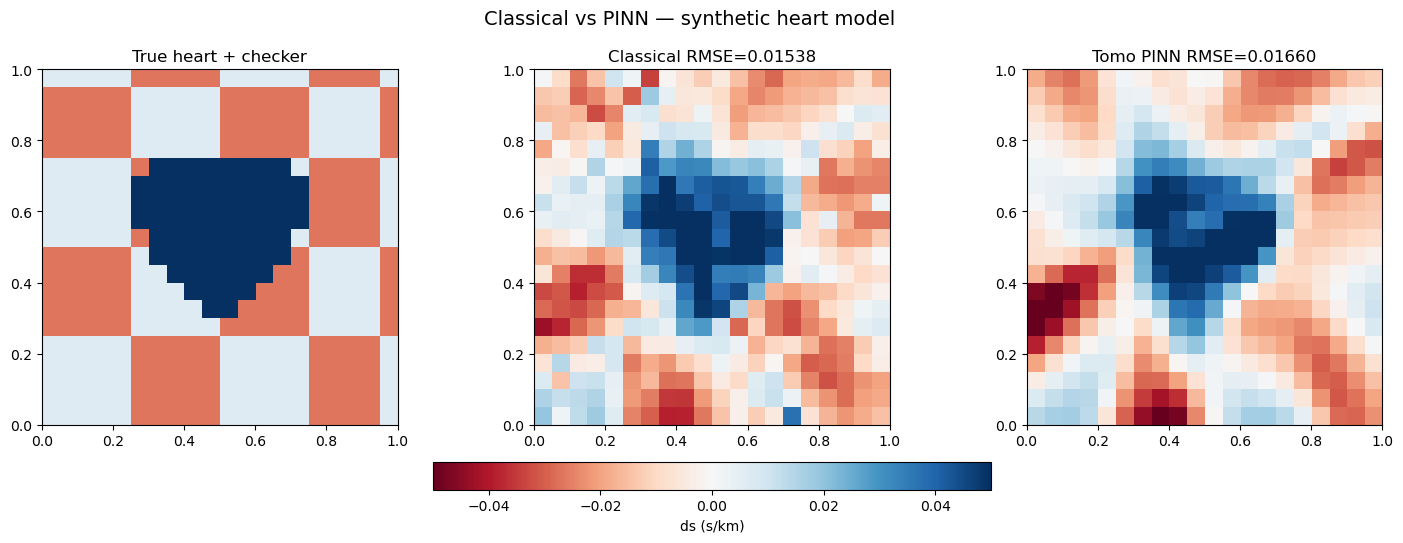

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vmin_p, vmax_p = -0.05, 0.05
kw2 = dict(aspect='equal', cmap='RdBu', origin='lower',
           vmin=vmin_p, vmax=vmax_p,
           extent=[0, 1, 0, 1])

im=axes[0].imshow(ds_true.reshape(20, 20), **kw2)
axes[0].set_title('True heart + checker')

axes[1].imshow(ds_classical.reshape(20, 20), **kw2)
axes[1].set_title(f'Classical RMSE={rmse_classical:.5f}')

axes[2].imshow(ds_pinn.reshape(20, 20), **kw2)
axes[2].set_title(f'Tomo PINN RMSE={rmse_pinn:.5f}')
 

fig.colorbar(im, ax=axes, location='bottom', label='ds (s/km)', shrink=0.4, pad=0.08)
plt.suptitle('Classical vs PINN — synthetic heart model', fontsize=14)
plt.show()



In [49]:
print(f"T_pred range: {T_pred.min():.4f} – {T_pred.max():.4f}")
print(f"tau_pred_physical range: {tau_pred_physical.min():.2f} – {tau_pred_physical.max():.2f}")
print(f"tau_ref range: {tau_ref.min():.2f} – {tau_ref.max():.2f}")

T_pred range: 0.2085 – 0.2678
tau_pred_physical range: 9.92 – 170.46
tau_ref range: 7.95 – 151.07


## Regularization Analysis

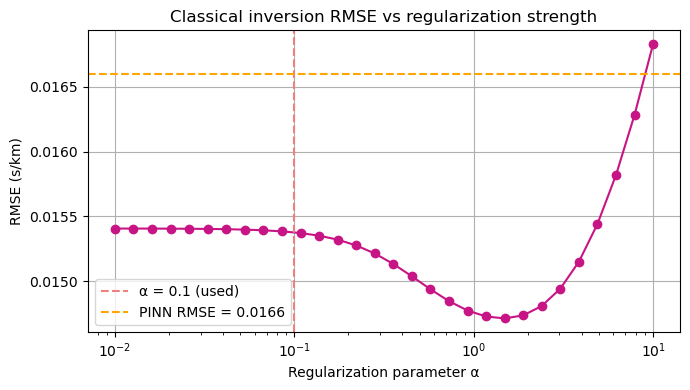

Optimal α = 1.4874
RMSE classical: 0.0154 s/km
RMSE PINN:      0.0166 s/km


In [140]:

alphas = np.logspace(-2, 1, 30)
rmse_alpha = []
for a in alphas:
    ds_inv = np.linalg.inv(G.T @ G + a**2 * LtL) @ G.T @ d_noisy
    rmse_alpha.append(np.sqrt(np.mean((ds_true - ds_inv)**2)))

plt.figure(figsize=(7, 4))
plt.semilogx(alphas, rmse_alpha, 'o-', color='mediumvioletred')
plt.axvline(0.1, color='lightcoral', linestyle='--', label='α = 0.1 (used)')
plt.axhline(rmse_pinn, color='orange', linestyle='--', label=f'PINN RMSE = {rmse_pinn:.4f}')
plt.xlabel('Regularization parameter α')
plt.ylabel('RMSE (s/km)')
plt.title('Classical inversion RMSE vs regularization strength')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
print(f"Optimal α = {alphas[np.argmin(rmse_alpha)]:.4f}")


print(f"RMSE classical: {rmse_classical:.4f} s/km")
print(f"RMSE PINN:      {rmse_pinn:.4f} s/km")

The plot shows how sensitive the Classical methode is to $\alpha$,  and where the PINN sits relativly to the optimal $\alpha$ for thr Classical

## Residual map 

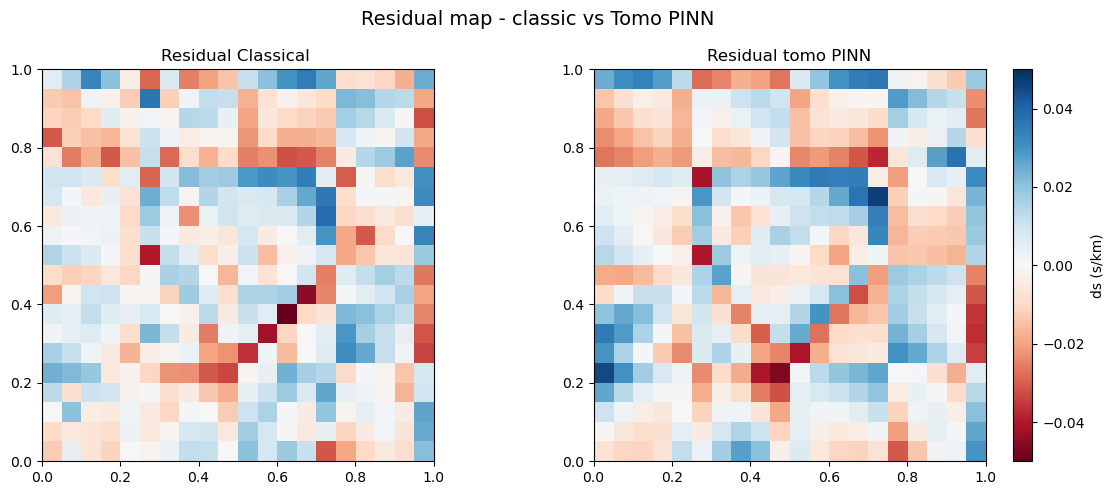

In [102]:
res_classical = ds_true - ds_classical
res_pinn      = ds_true - ds_pinn

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
kw = dict(aspect='equal', cmap='RdBu', origin='lower',
          vmin=-0.05, vmax=0.05,
          extent=[0, 1, 0, 1], interpolation='nearest')

im = axes[0].imshow(res_classical.reshape(20, 20), **kw)
axes[0].set_title(f'Residual Classical ')

axes[1].imshow(res_pinn.reshape(20, 20), **kw)
axes[1].set_title('Residual tomo PINN')


plt.colorbar(im, ax=axes[1], label='ds (s/km)')
plt.suptitle('Residual map - classic vs Tomo PINN', fontsize=14)
plt.tight_layout(); plt.show()

The residual maps show where each method fails spatially. Both methods show the largest errors at the domain edges, and more above the heart than under. The PINN residual map shows sharper, more structured squared patterns, and the heart parttern is more regonized. 

## Analysis

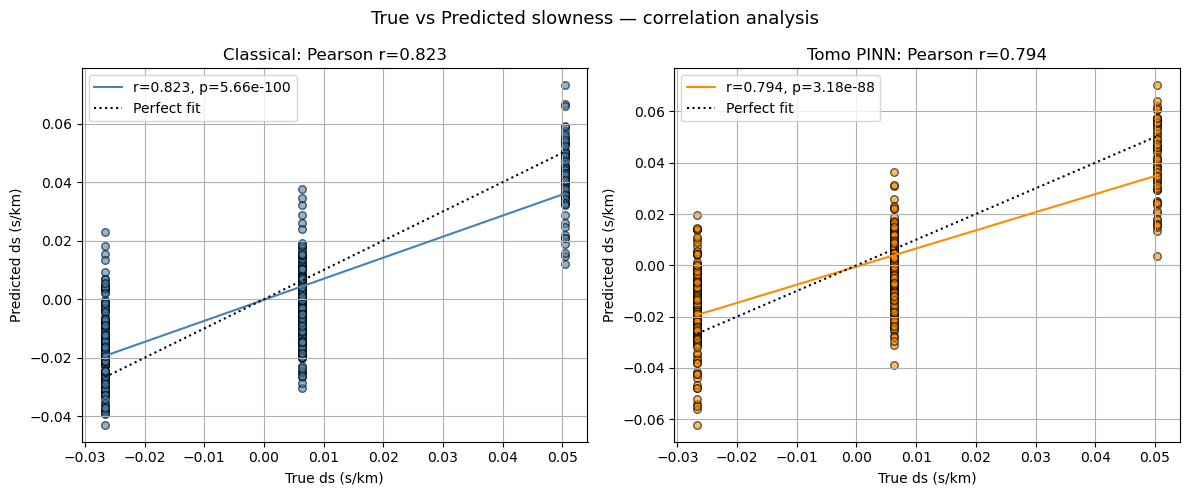

Classical — Pearson r: 0.823,     p-value: 5.66e-100, r2: 0.68
PINN      — Pearson r: 0.794,     p-value: 3.18e-88, r2: 0.63


In [ ]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ds_pred, label, color in zip(axes,
    [ds_classical, ds_pinn],
    ['Classical', 'Tomo PINN'],
    ['steelblue', 'darkorange']):
    

    r, p = pearsonr(ds_true, ds_pred)
    # regression line
    m = LinearRegression().fit(ds_true.reshape(-1,1), ds_pred)
    r2 =  r2_score(ds_pred, m.predict(ds_true.reshape(-1,1)))
    
    
    ax.scatter(ds_true, ds_pred, color=color, alpha=0.6, edgecolors='k', s=30)
    x_line = np.linspace(ds_true.min(), ds_true.max(), 100)
    ax.plot(x_line, m.predict(x_line.reshape(-1,1)), label=f'r={r:.3f}, p={p:.2e}', color= color)
    ax.plot(x_line, x_line, 'k:', label= 'Perfect fit')
    ax.set_xlabel('True ds (s/km)')
    ax.set_ylabel('Predicted ds (s/km)')
    ax.set_title(f'{label}: Pearson r={r:.3f}')
    ax.legend(); ax.grid(True)

plt.suptitle('True vs Predicted slowness — correlation analysis', fontsize=13)
plt.tight_layout(); plt.show()

r_classical, p_classical = pearsonr(ds_true, ds_classical)
r_pinn, p_pinn = pearsonr(ds_true, ds_pinn)
r2_classical= r2_score(ds_classical, m.predict(ds_true.reshape(-1,1)))
r2_pinn= r2_score(ds_pinn, m.predict(ds_true.reshape(-1,1)))

print(f"Classical_Pearson r: {r_classical:.3f},     p-value: {p_classical:.2e}, r2: {r2_classical:.2f}")
print(f"PINN_ Pearson r: {r_pinn:.3f},     p-value: {p_pinn:.2e}, r2: {r2_pinn:.2f}")





The comparsing between classical and  PINN inversion methods hows that the clasical method "outpreform" the PINN. The plot shows how both methods underestimates the amplitude of anomaly. Both lines fall above the perfect fit line for negative slowness, and fall below the perfect fit for positiv slowness. The classical regression line sits closer the 
perfect fit -> $R$ =  0.823 and $R^2$= 0.794, than the PINN -> $R$ = 0.68 and $R^2$ = 0.63). confirming the classical method recovers the slowness field more accurately.
P-value:

## Conclusions

### Summary of Methods

This project compared classical Tikhonov-regularized tomographic inversion and a Physics-Informed Neural Network (PINN) for recovering a synthetic heart-shaped low-velocity zone from 118 noisy seismic travel-time observations on a 20×20 grid. Before attempting the inverse problem, an eikonal PINN was trained on the forward problem to validate that the physics can be learned by a neural network.

### Forward Problem - Eikonal PINN
The eikonal PINN solved the forward problem, where the slowness field is given and the network predicts the travel-time field $\tau(x,y)$. The source is placed at $[0.5,\; 0.5]$. The loss converged to $1.6 \times 10^{-5}$, which is below the target at $10^{-4}$. In this case, the eikonal PDE is satisfied. The difference map shows higher travel times in the center, indicating that the PINN correctly predicts longer travel times inside the low-velocity heart, consistent with the known slowness structure. This confirms that the network architecture and training setup are capable of learning the underlying physics.

### Inverse Problem - Classical vs. Tomo PINN  
The classical inversion outperformed the tomoPINN across all metrics: RMSE (0.01538 vs 0.01660 s/km), Pearson $R$ (0.823 vs 0.794), and $R^2$
$R^2$ (0.68 vs 0.63). Both methods successfully recovered the general shape of the heart anomaly, but neither reproduced the sharp boundaries, which is the direct consequence of regularization and sparse ray coverage at domain edges, as seen in the residual maps.

The tomographic PINN loss curve is much noisier than the eikonal loss. It has several large spikes during training. This reflects how the PINN struggles with the inverse problem. The network finds it difficult to fit 118 noisy travel times as well as maintain a smooth slowness field. The loss decreases from 4.9 to 0.013 over 30000 epochs, but did not converge to the target threshold. The eikonal PINN, in contrast, converged smoothly because it only has to solve the forward problem where the slowness is already known.
The PINN residual map indicates it's struggling more to recover the sharp slowness contrast at the edges of the low-velocity zone. The PINN penalizes sharp gradients during training, so it struggles to recover the hard edge boundaries. The classical method doesn't have this problem in the same way. Its smoothing operator spreads the error more evenly across all blocks rather than concentrating it at boundaries. Both methods show the largest errors at the domain edges, and more above the heart than under. This is because blocks near the edges and corners are sampled by fewer rays, which limits inversion quality at those points.

### Correlation and Regression Analysis
The comparing between classical and PINN inversion methods shows that the
classical method "outperforms" the PINN. The scatter plots show how both methods underestimate the amplitude of the anomaly. Both lines fall above the perfect fit line for negative slowness, and fall below the perfect fit for positive slowness. The classical regression line sits closer to the perfect fit with $R = 0.823$ and $R^2 = 0.68$, compared to the PINN with $R = 0.794$ and $R^2 = 0.63$. Both p-values are extremely small ($5.66 \times 10^{-100}$ and $3.18 \times 10^{-88}$), confirming the correlations are statistically significant and the classical method recovers the slowness field more accurately.

### Regularization Sensitivity
The regularization sweep showed the optimal $\alpha^* \approx 1.49$, meaning the $\alpha = 0.1$ used is suboptimal. The plot shows how sensitive the classical method is to $\alpha$, and where the PINN sits relatively to the optimal $\alpha$ for the classical. At $\alpha^*$, the classical RMSE reaches $0.01538$ s/km vs tomoPINN RMSE of $0.01660$ s/km. The PINN RMSE is above the classical curve's minimum, confirming classical inversion is the better method for this dataset and setup.

### Limitations and Future Work
The limitations in this project includes a coarse 20×20 grid, single source for the eikonal PINN, and 118 rays and 400 unknowns which gives an underdetermined system. Using the optimal $\alpha$* =1.49 instead of $\alpha$ = 0.1 and a finer grid could be used to make the classical inversion more optimal. For the PINN, using adaptive loss weighting where the balance between the data loss and the smoothness loss changes during training could help the network converge better. Adding more collocation points near the heart boundaries and training for more epochs could also improve the result. The fact that the eikonal PINN performed well as a forward solver but the tomoPINN showed unstable training shows that the inverse problem is fundamentally harder than the forward problem, which is a well-known result in geophysics.


## Acknowledgement

Thanks to the course instructor for inspiring and useful exercises throughout the semester, both on the machine learning side and on geologically interesting topics. Correlation analysis and approaches from week 8 were directly applied in this project. The tomography code and ray-path matrix setup is adapted from the EPS130 Seismology notebook by Weiqiang Zhu at UC Berkeley. The PINN architecture and training approach was inspired by Raissi et al. (2019) and Smith et al. (2021). The eikonal PINN implementation was also inspired by the PyTorch eikonal solver notebook by Cui Yang and the PINNs for optics eikonal notebook by IrisFDTD, as well as the PINNs lecture by Steve Brunton.


## Work Cited

- Zhu, W. EPS130 Seismology tomography notebook, UC Berkeley. 
  https://github.com/AI4EPS/EPS130_Seismology

- Shearer, P.M. (2019). *Introduction to Seismology* (3rd ed.). 
  Cambridge University Press

- Raissi, M., Perdikaris, P. & Karniadakis, G.E. (2019). Physics-informed neural 
  networks. *Journal of Computational Physics*, 378, 686–707.

- Smith, J.D., Azizzadenesheli, K. & Ross, Z.E. (2021). EikoNet: Solving the 
  Eikonal equation with deep neural networks. *IEEE Transactions on Geoscience 
  and Remote Sensing*, 59(12), 10685–10696.

- Cui, Y. PINN Eikonal Solver (PyTorch). GitHub repository. https://github.com/     cuiyang512/Pinns-Eikonal-Solver-Pytorch/blob/main/PINN_Eikonal_Solver.ipynb

- IrisFDTD. PINNs for education: PINN for optics eikonal. GitHub repository.        https://github.com/IrisFDTD/PINNs-for-education/blob/main/PINN_for_optics_eikonal.ipynb

- Brunton, S. (2024). Physics Informed Neural Networks (PINNs) [Video]. YouTube. https://www.youtube.com/watch?v=-zrY7P2dVC4